# Exercises XP: Text Preprocessing, NER, POS, and Word2Vec

Use this guided notebook to follow the platform instructions step by step. Prefilled cells are ready to run; cells marked TODO expect your code or analysis.

## What you will learn
- Clean and normalize raw reviews with tokenization, stopword removal, and lemmatization.
- Extract linguistic features with named entity recognition (NER) and part-of-speech (POS) tagging.
- Train a simple Word2Vec model and interpret its vector dimensions.
- Visualize word embeddings to reason about semantic neighborhoods.

## What you will create
- A `preprocess_text` function that lowercases, strips punctuation, removes stopwords, and lemmatizes.
- `perform_ner` and `perform_pos_tagging` helpers to analyze raw vs cleaned text.
- A Word2Vec model plus a helper to plot embeddings for inspection.

> Learning point
> Run the setup cells once, then progress through each exercise sequentially. Print intermediate results to verify every helper works before moving on.

## Setup · install libraries
Run once to install spaCy, nltk, gensim, and plotting utilities.

In [1]:
%pip install --quiet spacy nltk gensim matplotlib seaborn --upgrade

Note: you may need to restart the kernel to use updated packages.


In [17]:
import nltk
from spacy.cli import download as spacy_download
import spacy

resources = [
    "punkt",
    "punkt_tab",
    "wordnet",
    "omw-1.4",
    "stopwords",
    "averaged_perceptron_tagger",
    "averaged_perceptron_tagger_eng",
    "tagsets",
    "maxent_ne_chunker_tab",
    "words" # Added this line
]
for res in resources:
    nltk.download(res, quiet=True)

spacy_download("en_core_web_sm")

nlp = spacy.load("en_core_web_sm")
print("spaCy pipeline:", nlp.pipe_names)

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.
spaCy pipeline: ['tok2vec', 'tagger', 'parser', 'attribute_ruler', 'lemmatizer', 'ner']


## Exercise 1 · Explore text preprocessing, NER, and POS tags

Here is the dataset you will reuse in every step.

In [3]:
data = {
    'Review': [
        "At McDonald's the food was ok and the service was bad.",
        "I would not recommend this Japanese restaurant to anyone.",
        "I loved this restaurant when I traveled to Thailand last summer.",
        "The menu of Loving has a wide variety of options.",
        "The staff was friendly and helpful at Google's employees restaurant.",
        "The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.",
        "I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.",
        "The sushi at Sushi Express is always fresh and flavorful.",
        "The steakhouse on Main Street has a cozy atmosphere and excellent steaks.",
        "The dessert selection at Sweet Treats is to die for!"
    ]
}
raw_reviews = data['Review']
raw_reviews


["At McDonald's the food was ok and the service was bad.",
 'I would not recommend this Japanese restaurant to anyone.',
 'I loved this restaurant when I traveled to Thailand last summer.',
 'The menu of Loving has a wide variety of options.',
 "The staff was friendly and helpful at Google's employees restaurant.",
 'The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.',
 'I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.',
 'The sushi at Sushi Express is always fresh and flavorful.',
 'The steakhouse on Main Street has a cozy atmosphere and excellent steaks.',
 'The dessert selection at Sweet Treats is to die for!']

### 1.1 Build `preprocess_text()`
Create a function that:
1. Lowercases and tokenizes text.
2. Removes punctuation tokens.
3. Removes English stopwords.
4. Applies a lemmatizer.
5. Returns the cleaned string joined by spaces.

Print the processed reviews to confirm every stage works.

In [8]:
import re
import string
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk import pos_tag, word_tokenize, ne_chunk

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()


def preprocess_text(text: str) -> str:
    """Lowercase, tokenize, strip punctuation, drop stopwords, and lemmatize a review."""
    # Lowercase the text first for consistent processing
    text = text.lower()
    # tokenize the text (hint: nltk.word_tokenize)
    tokens = nltk.word_tokenize(text)
    # remove punctuation tokens and filter out stopwords
    tokens = [token for token in tokens if token not in string.punctuation and token not in stop_words]
    # TODO: lemmatize remaining tokens
    lemmatized_tokens = [lemmatizer.lemmatize(token) for token in tokens]
    # TODO: join back into a single cleaned string
    cleaned_text = " ".join(lemmatized_tokens)
    return cleaned_text

### 1.2 Create a cleaned dataset
Apply `preprocess_text` to every review and keep both raw and cleaned versions side by side.

In [7]:
# TODO: apply preprocess_text to every review and keep both raw and cleaned versions
cleaned_reviews = [preprocess_text(review) for review in raw_reviews]

if cleaned_reviews is None:
    raise ValueError("Set cleaned_reviews by applying preprocess_text to raw_reviews.")

for raw, cleaned in zip(raw_reviews, cleaned_reviews):
    print(f"RAW: {raw}")
    print(f"CLEANED: {cleaned}\n")


RAW: At McDonald's the food was ok and the service was bad.
CLEANED: mcdonald 's food ok service bad

RAW: I would not recommend this Japanese restaurant to anyone.
CLEANED: would recommend japanese restaurant anyone

RAW: I loved this restaurant when I traveled to Thailand last summer.
CLEANED: loved restaurant traveled thailand last summer

RAW: The menu of Loving has a wide variety of options.
CLEANED: menu loving wide variety option

RAW: The staff was friendly and helpful at Google's employees restaurant.
CLEANED: staff friendly helpful google 's employee restaurant

RAW: The ambiance at Bella Italia is amazing, and the pasta dishes are delicious.
CLEANED: ambiance bella italia amazing pasta dish delicious

RAW: I had a terrible experience at Pizza Hut. The pizza was burnt, and the service was slow.
CLEANED: terrible experience pizza hut pizza burnt service slow

RAW: The sushi at Sushi Express is always fresh and flavorful.
CLEANED: sushi sushi express always fresh flavorful

RAW

### 1.3 Named Entity Recognition (NER)
Create `perform_ner(text)` that returns `(entity, label_)` pairs using `en_core_web_sm`. Test it on a few reviews.

In [9]:
def perform_ner(text: str):
    """Return (entity, label) pairs found by spaCy."""
    # Run the spaCy pipeline on the text
    doc = nlp(text)
    # Collect each entity text and its label_
    entities = [(ent.text, ent.label_) for ent in doc.ents]
    return entities


### 1.4 Part-of-Speech tagging (POS)
Create `perform_pos_tagging(text)` using `nltk.pos_tag`. Test it on both raw and cleaned text.

Use `nltk.help.upenn_tagset('NN')` to recall tag meanings if needed.

In [10]:
from nltk import pos_tag, word_tokenize

def perform_pos_tagging(text: str):
    """Return POS tags for a given text."""
    # TODO: tokenize the text
    tokens = nltk.word_tokenize(text)
    # TODO: call nltk.pos_tag on the tokens
    tagged = pos_tag(tokens)
    return tagged


### 1.5 Apply NER and POS on raw vs cleaned text
Compare outputs on the same entries to see how preprocessing affects tagging.

In [18]:
sample_texts = raw_reviews[:2]

print("NER on raw text")
# TODO: loop through sample_texts and print perform_ner results
for text in sample_texts:
    print(perform_ner(text))

print("\nNER on cleaned text")
# TODO: repeat using cleaned_reviews
cleaned_sample_texts = cleaned_reviews[:2]
for text in cleaned_sample_texts:
    print(perform_ner(text))

print("\nPOS tags on raw text")
# TODO
for text in sample_texts:
    print(perform_pos_tagging(text))

print("\nPOS tags on cleaned text")
# TODO
for text in cleaned_sample_texts:
    print(perform_pos_tagging(text))

NER on raw text
(S
  At/IN
  (ORGANIZATION McDonald/NNP)
  's/POS
  the/DT
  food/NN
  was/VBD
  ok/JJ
  and/CC
  the/DT
  service/NN
  was/VBD
  bad/JJ
  ./.)
(S
  I/PRP
  would/MD
  not/RB
  recommend/VB
  this/DT
  (GPE Japanese/JJ)
  restaurant/NN
  to/TO
  anyone/NN
  ./.)

NER on cleaned text
(S mcdonald/NN 's/POS food/NN ok/JJ service/NN bad/JJ)
(S would/MD recommend/VB japanese/JJ restaurant/NN anyone/NN)

POS tags on raw text
[('At', 'IN'), ('McDonald', 'NNP'), ("'s", 'POS'), ('the', 'DT'), ('food', 'NN'), ('was', 'VBD'), ('ok', 'JJ'), ('and', 'CC'), ('the', 'DT'), ('service', 'NN'), ('was', 'VBD'), ('bad', 'JJ'), ('.', '.')]
[('I', 'PRP'), ('would', 'MD'), ('not', 'RB'), ('recommend', 'VB'), ('this', 'DT'), ('Japanese', 'JJ'), ('restaurant', 'NN'), ('to', 'TO'), ('anyone', 'NN'), ('.', '.')]

POS tags on cleaned text
[('mcdonald', 'NN'), ("'s", 'POS'), ('food', 'NN'), ('ok', 'JJ'), ('service', 'NN'), ('bad', 'JJ')]
[('would', 'MD'), ('recommend', 'VB'), ('japanese', 'JJ'), ('

## Exercise 2 · Plotting word embeddings

### 2.1 Train a Word2Vec model
Vectorize the preprocessed/tokenized dataset with `Word2Vec` from `gensim.models`. Reuse the cleaned text and adjust parameters like `vector_size`, `window`, and `sg`.

In [22]:
from gensim.models import Word2Vec

# TODO: ensure cleaned_reviews is defined from Exercise 1
if cleaned_reviews is None:
    raise ValueError("Set cleaned_reviews by applying preprocess_text to raw_reviews.")
# Tokenize on whitespace after preprocessing
tokenized_reviews = [review.split() for review in cleaned_reviews]

# TODO: train the Word2Vec model
w2v_model = Word2Vec(vector_size=100, window=5, sg=0, min_count=1) # Initialize without sentences, setting min_count to 1
w2v_model.build_vocab(tokenized_reviews) # Build vocabulary
w2v_model.train(tokenized_reviews, total_examples=w2v_model.corpus_count, epochs=w2v_model.epochs) # Train the model
w2v_model

### 2.2 Inspect embedding dimensions
Print and interpret the vector size and vocabulary size from the fitted model.

In [23]:
# TODO: print the vector size and vocabulary size of your model
print("Vector size:", w2v_model.vector_size)
print("Vocabulary size:", len(w2v_model.wv.key_to_index))


Vector size: 100
Vocabulary size: 56


### **Interpretation** :
* Vector size: 100. Cela indique que chaque mot du vocabulaire est représenté par un vecteur de 100 dimensions. Chaque dimension capture une caractéristique sémantique différente du mot. Une taille de vecteur plus importante permet une représentation du sens des mots, mais nécessite également davantage de données pour un entraînement efficace.

* Vocabulary size: 56. Cela signifie que le modèle Word2Vec a appris les représentations vectorielles de 56 mots uniques de votre ensemble de données de cleaned_reviews. Seuls les mots apparaissant au moins **min_count** (fixé à 1) fois dans les données d'entraînement sont inclus dans ce vocabulaire.

### 2.3 Plot word embeddings
Complete `plot_word_embeddings(model)` to scatter-plot the first two dimensions of the learned vectors and annotate each point with its word. Discuss whether related words cluster together.

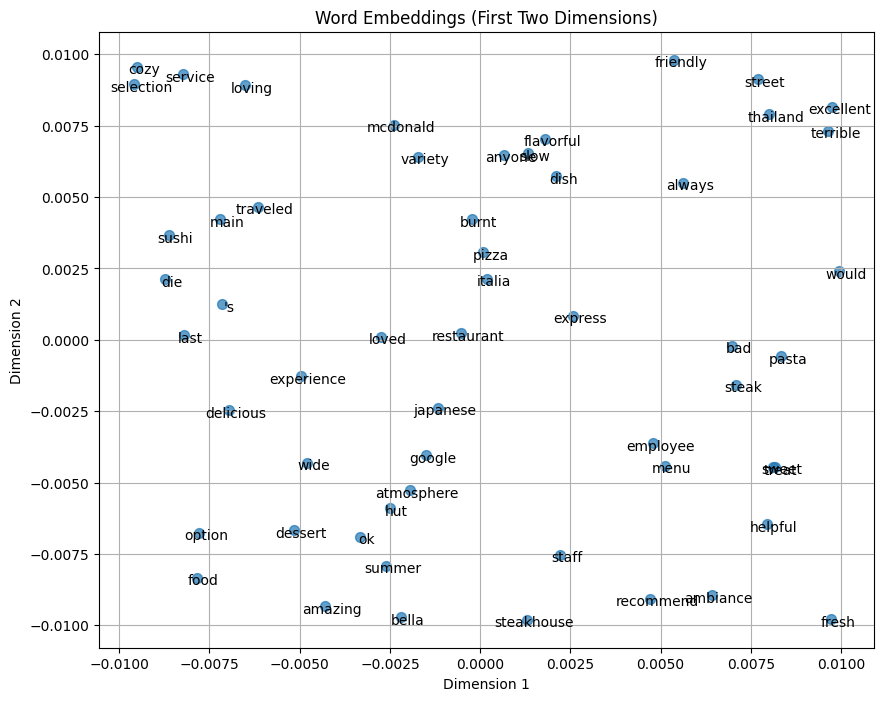

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# TODO: complete the plot_word_embeddings function
def plot_word_embeddings(model, words=None):
    if words is None:
        # Get all words from the vocabulary
        labels = model.wv.index_to_key
        vectors = model.wv.vectors
    else:
        # Filter words and their vectors
        labels = [word for word in words if word in model.wv.index_to_key]
        vectors = np.array([model.wv[word] for word in labels])

    # Take the first two dimensions for 2D plotting
    # If the vector size is less than 2, we need to handle it or plot in 1D.
    if vectors.shape[1] < 2:
        print("Vector size is too small for 2D plotting.")
        return

    # Extract x and y coordinates from the first two dimensions
    x_coords = vectors[:, 0]
    y_coords = vectors[:, 1]

    plt.figure(figsize=(10, 8))
    plt.scatter(x_coords, y_coords, s=50, alpha=0.7)

    for i, label in enumerate(labels):
        plt.annotate(label, (x_coords[i], y_coords[i]), textcoords="offset points", xytext=(5, -5), ha='center')

    plt.title('Word Embeddings (First Two Dimensions)')
    plt.xlabel('Dimension 1')
    plt.ylabel('Dimension 2')
    plt.grid(True)
    plt.show()

# TODO: call the plotting function using your trained model
plot_word_embeddings(w2v_model)

### 2.4 Go further
- Experiment with different preprocessing (e.g., bigrams, stemming vs lemmatization).
- Tune Word2Vec hyperparameters and compare the plots.
- Try dimensionality reduction (PCA/t-SNE) for richer visualizations.